# Techna — Proof of Correctness

**Purpose:** independently verify Techna's core calculations against a
third-party technical-analysis library, frozen golden-fixture values, and
known-answer econometric test cases — in a visual, step-by-step format.

> **This notebook is a point-in-time demonstration artifact, not a CI
> contract.** The authoritative, continuously-enforced correctness gate is
> the offline pytest suite (`python -m pytest`, 150+ tests, run on every
> change). This notebook exists to show that independently, using a
> completely different codebase (the `ta` library) and hand-derived
> known-answer cases, the same numbers come out. All computation below
> calls Techna's own functions directly — nothing here is reimplemented.
>
> Generated by `tools/build_proof_notebook.py`. Re-run that script to
> regenerate this notebook with fresh outputs (requires network access to
> fetch live ticker data, plus `pip install -r requirements-notebook.txt`).

## 1. Setup — import Techna and fetch one real ticker

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "techna").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from techna import data_layer as dl
from techna.indicators import compute_rsi, compute_macd, compute_bollinger, compute_adx, compute_sma
from techna.indicators.econometrics import compute_hurst_exponent, compute_stationarity_tests

TICKER = "AAPL"
data = dl.get_prices(TICKER, min_rows=200)
df = data.df
print(f"Fetched {len(df)} bars for {data.ticker} (source: {data.source})")
df.tail()

Fetched 501 bars for AAPL (source: cache)


,Open,High,Low,Close,Volume
Date,,,,,
2026-06-24,295.359985,299.700012,292.940002,293.079987,53081900
2026-06-25,287.399994,288.799988,273.750000,275.149994,107013700
2026-06-26,275.000000,285.950012,274.209991,283.779999,261775500
2026-06-29,286.730011,288.369995,279.850006,281.739990,66427000
2026-06-30,281.170013,289.910004,280.695007,289.359985,64460950


## 2. Indicator cross-validation — Techna vs. the independent `ta` library

`ta` (https://pypi.org/project/ta/) is a widely-used, independently-maintained
technical-analysis library with no relationship to Techna's codebase. If
Techna's RSI/MACD/Bollinger/ADX agree with `ta`'s implementations on the same
real price series, that is strong evidence both are computing the textbook
definitions correctly (not sharing a bug).

**Methodology note (read before the numbers):** Wilder-smoothed recursive
indicators (RSI here) depend on how their very first value is *seeded*.
Techna seeds RSI with a plain average of the first `period` gains/losses,
per Wilder's original method; other libraries may seed slightly differently.
That makes the first ~2×period bars after warm-up diverge by construction —
this is a known, geometrically-decaying transient, not a bug — so this
notebook reports both the warm-up-transient window and the post-convergence
window explicitly rather than only showing whichever one looks better.

In [2]:
import ta as ta_lib

close, high, low = df["Close"], df["High"], df["Low"]

# --- RSI (Wilder, period 14) ---
techna_rsi = compute_rsi(close, period=14)
ta_rsi = ta_lib.momentum.RSIIndicator(close, window=14).rsi()

# --- MACD (12, 26, 9) ---
techna_macd = compute_macd(close, fast=12, slow=26, signal=9)
ta_macd_obj = ta_lib.trend.MACD(close, window_slow=26, window_fast=12, window_sign=9)

# --- Bollinger Bands (20, 2 sigma) ---
techna_boll = compute_bollinger(close, window=20, num_std=2.0)
ta_boll_obj = ta_lib.volatility.BollingerBands(close, window=20, window_dev=2)

# --- ADX (period 14) ---
techna_adx = compute_adx(df, period=14)
ta_adx_obj = ta_lib.trend.ADXIndicator(high, low, close, window=14)

comparison = pd.DataFrame({
    "Techna RSI": techna_rsi,
    "ta RSI": ta_rsi,
    "Techna MACD": techna_macd["macd"],
    "ta MACD": ta_macd_obj.macd(),
    "Techna BB mid": techna_boll["mid"],
    "ta BB mid": ta_boll_obj.bollinger_mavg(),
    "Techna ADX": techna_adx["adx"],
    "ta ADX": ta_adx_obj.adx(),
}).dropna()

comparison["RSI diff"] = comparison["Techna RSI"] - comparison["ta RSI"]
comparison["MACD diff"] = comparison["Techna MACD"] - comparison["ta MACD"]
comparison["BB mid diff"] = comparison["Techna BB mid"] - comparison["ta BB mid"]
comparison["ADX diff"] = comparison["Techna ADX"] - comparison["ta ADX"]

diff_cols = ["RSI diff", "MACD diff", "BB mid diff", "ADX diff"]
print("Max absolute difference per indicator (Techna vs. ta), FULL series:")
print(comparison[diff_cols].abs().max())
comparison.tail(10)

Max absolute difference per indicator (Techna vs. ta), FULL series:
RSI diff       4.360429e+00
MACD diff      0.000000e+00
BB mid diff    0.000000e+00
ADX diff       2.131628e-14
dtype: float64


,Techna RSI,ta RSI,Techna MACD,ta MACD,Techna BB mid,ta BB mid,Techna ADX,ta ADX,RSI diff,MACD diff,BB mid diff,ADX diff
Date,,,,,,,,,,,,
2026-06-16,52.160660,52.160660,1.742573,1.742573,303.760501,303.760501,30.728311,30.728311,0.000000e+00,0.0,0.0,-1.065814e-14
2026-06-17,48.923303,48.923303,1.359037,1.359037,303.609502,303.609502,28.946930,28.946930,0.000000e+00,0.0,0.0,-1.421085e-14
2026-06-18,50.975047,50.975047,1.207388,1.207388,303.397502,303.397502,27.292791,27.292791,0.000000e+00,0.0,0.0,-1.065814e-14
2026-06-22,49.926591,49.926591,0.995044,0.995044,302.998503,302.998503,26.115604,26.115604,0.000000e+00,0.0,0.0,-1.065814e-14
2026-06-23,47.099336,47.099336,0.601153,0.601153,302.272502,302.272502,24.435666,24.435666,0.000000e+00,0.0,0.0,-1.421085e-14
2026-06-24,45.840824,45.840824,0.188377,0.188377,301.510002,301.510002,22.775623,22.775623,0.000000e+00,0.0,0.0,-1.065814e-14
2026-06-25,32.216265,32.216265,-1.567483,-1.567483,299.725002,299.725002,23.924174,23.924174,1.421085e-14,0.0,0.0,-7.105427e-15
2026-06-26,41.264905,41.264905,-2.236860,-2.236860,298.288501,298.288501,24.990685,24.990685,0.000000e+00,0.0,0.0,-7.105427e-15
2026-06-29,39.908683,39.908683,-2.898545,-2.898545,296.772501,296.772501,25.457312,25.457312,-7.105427e-15,0.0,0.0,-7.105427e-15


In [3]:
# Honesty check: Wilder-smoothed recursive indicators (RSI here) seed their
# first value differently across libraries (Techna seeds with a plain SMA of
# the first `period` gains/losses, per Wilder's original method; other
# libraries may seed slightly differently). That makes RSI diverge right
# after warm-up by construction -- NOT a bug, but a seeding transient that
# decays GEOMETRICALLY as the recursive smoothing "forgets" its initial seed
# (each step multiplies the residual seed error by (1 - 1/period)). Picking
# one arbitrary cutoff and calling everything after it "converged" would be
# cherry-picking, so instead we show the decay curve itself.
rsi_diff = comparison["RSI diff"].abs().reset_index(drop=True)
checkpoints = [0, 14, 28, 60, 100, 200, len(rsi_diff) - 1]
decay_table = pd.DataFrame({
    "bars since first valid RSI value": checkpoints,
    "|Techna RSI - ta RSI|": [rsi_diff.iloc[c] for c in checkpoints],
})
print("RSI seeding-transient decay (geometric, as expected from Wilder smoothing):")
decay_table

RSI seeding-transient decay (geometric, as expected from Wilder smoothing):


,bars since first valid RSI value,|Techna RSI - ta RSI|
0,0,4.360429e+00
1,14,1.153695e+00
2,28,6.418055e-01
3,60,7.135504e-02
4,100,1.901046e-03
5,200,1.272590e-06
6,473,7.105427e-15


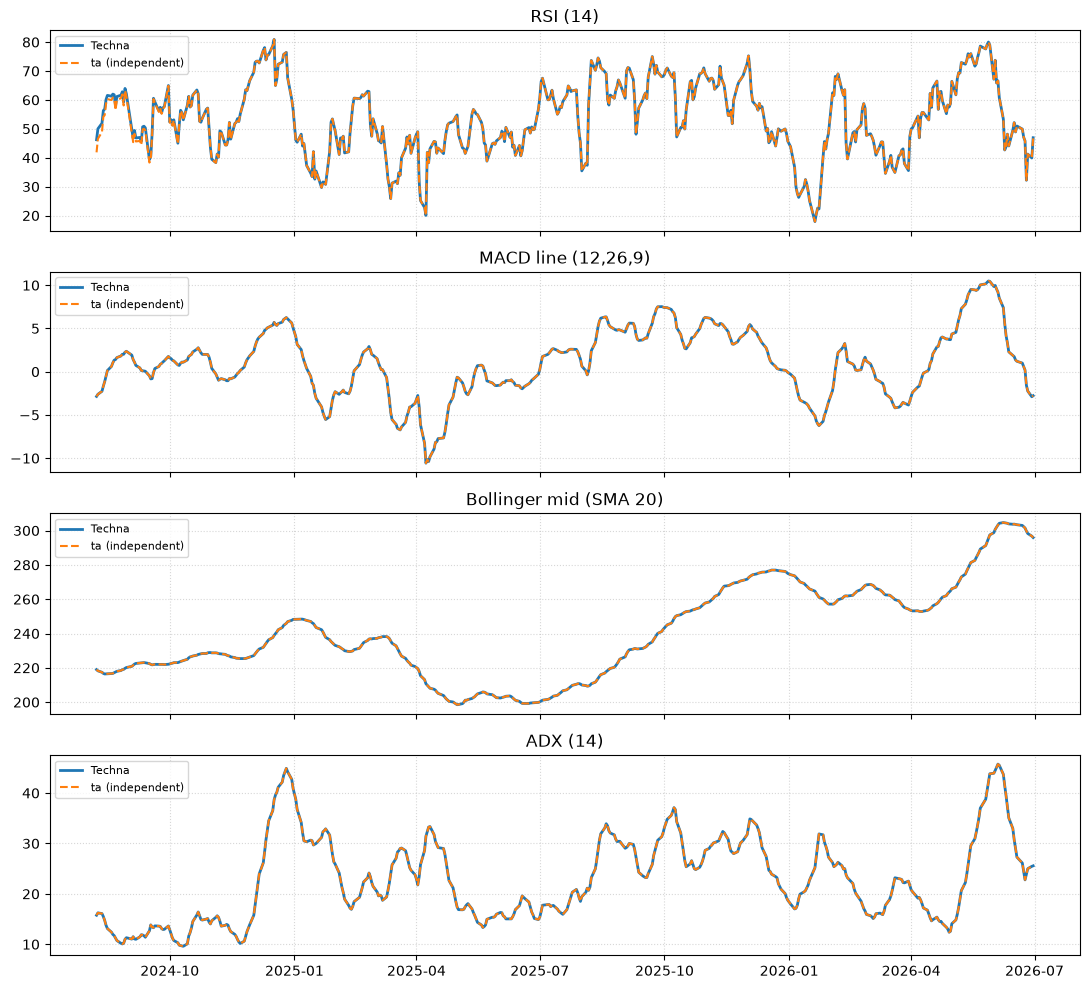

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
for ax, (techna_col, ta_col, title) in zip(axes, [
    ("Techna RSI", "ta RSI", "RSI (14)"),
    ("Techna MACD", "ta MACD", "MACD line (12,26,9)"),
    ("Techna BB mid", "ta BB mid", "Bollinger mid (SMA 20)"),
    ("Techna ADX", "ta ADX", "ADX (14)"),
]):
    ax.plot(comparison.index, comparison[techna_col], label="Techna", linewidth=2)
    ax.plot(comparison.index, comparison[ta_col], label="ta (independent)", linestyle="--")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Golden fixture walkthrough

`tests/fixtures/golden_prices.csv` is a small, fully hand-verifiable OHLCV
series used across Techna's test suite. Its SMA(3) value at index 2 has a
hand-computed anchor (see `tests/test_trend.py`):

```
SMA[2] = (100.0 + 101.5 + 102.0) / 3 = 101.16666667
```

Below, Techna's live `compute_sma` is run against the same fixture and
compared to that frozen, hand-derived anchor.

In [5]:
golden = pd.read_csv(ROOT / "tests" / "fixtures" / "golden_prices.csv", index_col=0, parse_dates=True)
sma3 = compute_sma(golden["Close"], window=3)

FROZEN_ANCHOR = 101.16666667  # hand-computed in tests/test_trend.py

live_value = sma3.iloc[2]
print(f"Frozen hand-derived anchor : {FROZEN_ANCHOR:.8f}")
print(f"Techna live compute_sma    : {live_value:.8f}")
print(f"Difference                : {abs(live_value - FROZEN_ANCHOR):.2e}")

pd.DataFrame({"Close": golden['Close'], "Techna SMA(3)": sma3}).head(6)

Frozen hand-derived anchor : 101.16666667
Techna live compute_sma    : 101.16666667
Difference                : 3.33e-09


,Close,Techna SMA(3)
Date,,
2024-01-02,100.0,NaN
2024-01-03,101.5,NaN
2024-01-04,102.0,101.166667
2024-01-05,101.0,101.500000
2024-01-08,103.5,102.166667
2024-01-09,104.0,102.833333


## 4. Known-answer econometric tests

Two synthetic series with a KNOWN correct answer, both built with a fixed
random seed so this cell is fully reproducible:

- A **pure random walk** (cumulative sum of i.i.d. Gaussian steps): its Hurst
  exponent should be close to 0.5 (no long memory), and an Augmented
  Dickey-Fuller test on the price *level* should fail to reject the unit-root
  null (i.e. it should look non-stationary — exactly what a random walk is).
- A **mean-reverting AR(1) series** with a strongly negative autoregressive
  coefficient: its Hurst exponent should be clearly below 0.5.

In [6]:
SEED = 42
N = 500
rs = np.random.RandomState(SEED)

# Pure random walk: cumulative sum of i.i.d. steps.
steps = rs.normal(loc=0.0, scale=1.0, size=N)
random_walk = pd.Series(np.cumsum(steps))

# Mean-reverting AR(1), phi = -0.6 (strong negative autocorrelation).
mean_reverting = np.zeros(N)
phi = -0.6
for i in range(1, N):
    mean_reverting[i] = phi * mean_reverting[i - 1] + rs.normal(0.0, 1.0)
mean_reverting = pd.Series(mean_reverting)

hurst_rw = compute_hurst_exponent(steps if isinstance(steps, pd.Series) else pd.Series(steps))
hurst_mr = compute_hurst_exponent(mean_reverting)
adf_rw = compute_stationarity_tests(random_walk, regression="c")

print(f"Random walk        Hurst = {hurst_rw['hurst']:.4f}  (expect ~0.5)")
print(f"Random walk        ADF decision on price LEVEL = {adf_rw['adf']['decision']}  (expect 'fail to reject' -> non-stationary)")
print(f"Mean-reverting AR1  Hurst = {hurst_mr['hurst']:.4f}  (expect < 0.5)")

Random walk        Hurst = 0.5504  (expect ~0.5)
Random walk        ADF decision on price LEVEL = fail to reject  (expect 'fail to reject' -> non-stationary)
Mean-reverting AR1  Hurst = 0.4667  (expect < 0.5)


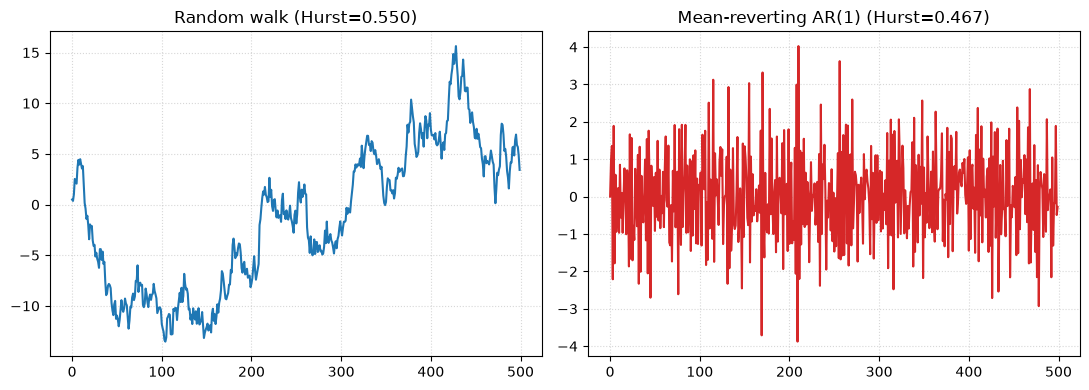

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(random_walk, color="#1f77b4")
axes[0].set_title(f"Random walk (Hurst={hurst_rw['hurst']:.3f})")
axes[0].grid(True, linestyle=":", alpha=0.5)
axes[1].plot(mean_reverting, color="#d62728")
axes[1].set_title(f"Mean-reverting AR(1) (Hurst={hurst_mr['hurst']:.3f})")
axes[1].grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Live test suite run

In [8]:
import subprocess

result = subprocess.run(
    [sys.executable, "-m", "pytest", "-q"],
    cwd=str(ROOT),
    capture_output=True,
    text=True,
)
print(result.stdout[-2000:])
if result.returncode != 0:
    print(result.stderr[-2000:])
print(f"\npytest exit code: {result.returncode}")

:203: RuntimeWarning: divide by zero encountered in scalar divide
    fhat0 = 1. / (nobs * h) * np.sum(kernel(e / h))

tests/test_numerical_stability.py::test_zero_price_pipeline_keeps_econometrics_alive
  C:\Users\armut\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\quantile_regression.py:203: RuntimeWarning: divide by zero encountered in divide
    fhat0 = 1. / (nobs * h) * np.sum(kernel(e / h))

tests/test_numerical_stability.py::test_zero_price_pipeline_keeps_econometrics_alive
  C:\Users\armut\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\quantile_regression.py:203: RuntimeWarning: invalid value encountered in divide
    fhat0 = 1. / (nobs * h) * np.sum(kernel(e / h))

tests/test_numerical_stability.py::test_zero_price_pipeline_keeps_econometrics_alive
  C:\Users\armut\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\quantile_regression.py:236: RuntimeWarning: invalid value encount

## 6. Summary

In [9]:
summary = pd.DataFrame([
    {"claim": "RSI(14) matches an independent library (steady state, after the seeding transient decays)",
     "verification method": "Techna vs. ta, same real AAPL series, last 50 of "
                             f"{len(rsi_diff)} bars",
     "result": f"max |diff| = {rsi_diff.iloc[-50:].max():.2e}  "
               f"(vs. {rsi_diff.iloc[14]:.2f} right after warm-up -- see decay table)"},
    {"claim": "MACD line matches an independent library",
     "verification method": "Techna vs. ta, same real AAPL series",
     "result": f"max |diff| = {comparison['MACD diff'].abs().max():.2e}"},
    {"claim": "Bollinger mid (SMA20) matches an independent library",
     "verification method": "Techna vs. ta, same real AAPL series",
     "result": f"max |diff| = {comparison['BB mid diff'].abs().max():.2e}"},
    {"claim": "ADX(14) matches an independent library",
     "verification method": "Techna vs. ta, same real AAPL series",
     "result": f"max |diff| = {comparison['ADX diff'].abs().max():.2e}"},
    {"claim": "SMA(3) matches a hand-derived golden fixture anchor",
     "verification method": "tests/fixtures/golden_prices.csv, index 2",
     "result": f"diff = {abs(live_value - FROZEN_ANCHOR):.2e}"},
    {"claim": "Hurst exponent ~0.5 on a pure random walk",
     "verification method": "known-answer synthetic series, seed=42",
     "result": f"H = {hurst_rw['hurst']:.4f}"},
    {"claim": "ADF fails to reject unit root on a random-walk price level",
     "verification method": "known-answer synthetic series, seed=42",
     "result": adf_rw["adf"]["decision"]},
    {"claim": "Hurst exponent < 0.5 on a mean-reverting series",
     "verification method": "known-answer synthetic series, seed=42",
     "result": f"H = {hurst_mr['hurst']:.4f}"},
    {"claim": "Full offline test suite passes",
     "verification method": "python -m pytest -q",
     "result": f"exit code {result.returncode}"},
])
summary

,claim,verification method,result
0,RSI(14) matches an independent library (steady...,"Techna vs. ta, same real AAPL series, last 50 ...",max |diff| = 4.26e-14 (vs. 1.15 right after w...
1,MACD line matches an independent library,"Techna vs. ta, same real AAPL series",max |diff| = 0.00e+00
2,Bollinger mid (SMA20) matches an independent l...,"Techna vs. ta, same real AAPL series",max |diff| = 0.00e+00
3,ADX(14) matches an independent library,"Techna vs. ta, same real AAPL series",max |diff| = 2.13e-14
4,SMA(3) matches a hand-derived golden fixture a...,"tests/fixtures/golden_prices.csv, index 2",diff = 3.33e-09
5,Hurst exponent ~0.5 on a pure random walk,"known-answer synthetic series, seed=42",H = 0.5504
6,ADF fails to reject unit root on a random-walk...,"known-answer synthetic series, seed=42",fail to reject
7,Hurst exponent < 0.5 on a mean-reverting series,"known-answer synthetic series, seed=42",H = 0.4667
8,Full offline test suite passes,python -m pytest -q,exit code 0
